In [ ]:
url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
!pip install conda-package-handling
!wget https://anaconda.org/conda-forge/ta-lib/0.5.1/download/linux-64/ta-lib-0.5.1-py311h9ecbd09_0.conda
!cph x ta-lib-0.5.1-py311h9ecbd09_0.conda
!mv ./ta-lib-0.5.1-py311h9ecbd09_0/lib/python3.11/site-packages/talib /usr/local/lib/python3.11/dist-packages/
import talib

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4079    0  4079    0     0   9481      0 --:--:-- --:--:-- --:--:--  9464
100  517k  100  517k    0     0   472k      0  0:00:01  0:00:01 --:--:--  472k
--2025-05-21 19:57:55--  https://anaconda.org/conda-forge/ta-lib/0.5.1/download/linux-64/ta-lib-0.5.1-py311h9ecbd09_0.conda
Resolving anaconda.org (anaconda.org)... 104.19.144.37, 104.19.145.37, 2606:4700::6813:9025, ...
Connecting to anaconda.org (anaconda.org)|104.19.144.37|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://binstar-cio-packages-prod.s3.amazonaws.com/5f738b4b78d4370a69f82984/673b62920c609ff6945bb24d?response-content-disposition=attachment%3B%20filename%3D%22ta-lib-0.5.1-py311h9ecbd09_0.conda%22%3B%20filename%2A%3DUTF-8%27%27ta-lib-0.5.1-py311h9ecbd09_0.conda&response-content-type=application%2Foctet-stream&X-Amz-Algorithm=

In [ ]:
# On MacOS, it's much easier
# brew install ta-lib
# pip install TA-lib

# RSI

The **Relative Strength Index (RSI)** is one of the most popular momentum indicators in technical analysis. It measures the **speed and magnitude of recent price changes** to evaluate whether a stock (or any asset) is **overbought** or **oversold**.

---

## 📐 Formula

RSI is calculated as:

$$
\text{RSI} = 100 - \left( \frac{100}{1 + RS} \right)
$$

Where:

$$
RS = \frac{\text{Average Gain over N periods}}{\text{Average Loss over N periods}}
$$

Typically, **N = 14 days**, though it can be adjusted.

---

## 📊 Step-by-Step Calculation

1. **Compute price changes** between consecutive closes.
2. Separate the changes into **gains** (positive changes) and **losses** (negative changes).
3. Calculate the **average gain** and **average loss** over the last N periods (usually 14).
4. Compute the **RS** (Relative Strength) = average gain / average loss.
5. Plug RS into the RSI formula.

* NOTE: The "change" is just P(t) - P(t-1)
* For negative changes, convert them to positive numbers
* "Average" change just refers to the sample mean of those changes

Q: What happens if all changes are positive?

Q: What happens if all changes are negative?

---

## 🎯 Interpretation

* **RSI > 70**: Asset may be **overbought** → potential reversal or pullback.
* **RSI < 30**: Asset may be **oversold** → potential rebound.
* **RSI ≈ 50**: Neutral momentum.

> ⚠️ Note: These thresholds are **guidelines**, not strict rules. RSI works best when combined with other indicators or signals.

---

## 🧠 Key Characteristics

| Feature       | Value                      |
| ------------- | -------------------------- |
| Output Range  | 0 to 100                   |
| Normal Range  | 30 to 70                   |
| Type          | Momentum oscillator        |
| Common Period | 14 (days or candles)       |
| Used For      | Trend strength & reversals |

---

## 🧪 Example (Pandas/TA-Lib)

### With TA-Lib:

```python
import talib
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
```

### With pandas-ta:

```python
import pandas_ta as ta
df['RSI'] = ta.rsi(df['Close'], length=14)
```


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


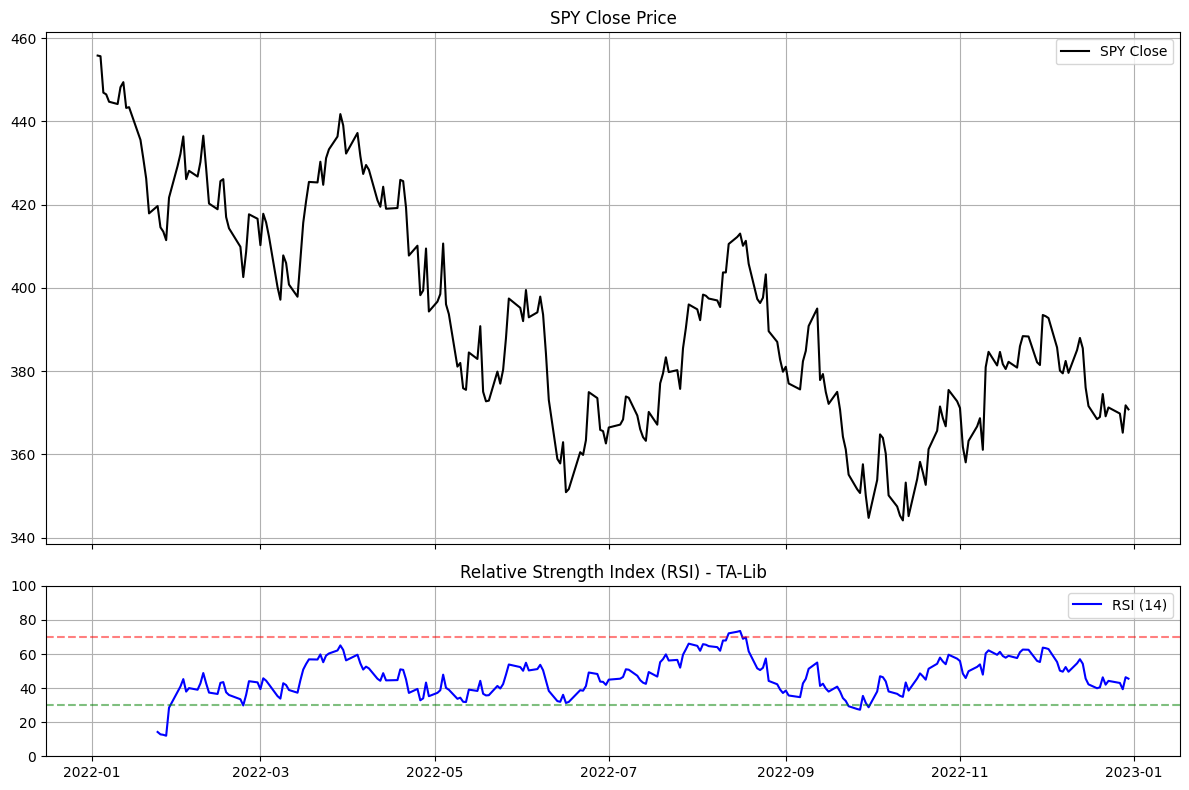

In [ ]:
import yfinance as yf
import talib
import matplotlib.pyplot as plt

# Step 1: Download SPY data
spy = yf.download('SPY', start='2022-01-01', end='2023-01-01')

# Step 2: Compute RSI using TA-Lib
x = talib.RSI(spy['Close'].to_numpy().flatten(), timeperiod=14)
spy['RSI'] = x

# Step 3: Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Close price
ax1.plot(spy.index, spy['Close'], label='SPY Close', color='black')
ax1.set_title('SPY Close Price')
ax1.legend()
ax1.grid(True)

# Plot RSI
ax2.plot(spy.index, spy['RSI'], label='RSI (14)', color='blue')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title('Relative Strength Index (RSI) - TA-Lib')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**MACD**, or **Moving Average Convergence Divergence**, is a technical analysis indicator used to identify price trends and momentum in securities. It calculates the difference between two exponential moving averages (EMAs) and helps traders determine potential entry and exit points for trades.

In short: MACD = EMA(12) - EMA(26)

What is EMA? Same as Polyak averaging earlier in the course.

smoothed[t] = a * original[t] + (1 - a) * smoothed[t-1]

Why is it "exponential"? See prerequisites!

---

## 🎯 Overview of MACD

**MACD** is based on the difference between two exponential moving averages (EMAs). It highlights changes in momentum by tracking the relationship between short-term and long-term moving averages.

---

## 🧮 The 3 Components of MACD

### 1. **MACD Line**

This is the **core of the indicator**.

$$
\text{MACD Line} = \text{EMA}_{\text{short}} - \text{EMA}_{\text{long}}
$$

* Typically:

  * Short EMA = 12-period
  * Long EMA = 26-period
* **Interprets** the momentum/trend:

  * Positive MACD: upward momentum
  * Negative MACD: downward momentum

---

### 2. **Signal Line**

$$
\text{Signal Line} = \text{EMA}_{\text{MACD line}}(9)
$$

* A 9-period EMA of the MACD line.
* Used as a **trigger for buy/sell signals**.
* **Crossovers** between the MACD line and signal line are key trading signals:

  * MACD crosses **above** signal → **bullish** (buy)
  * MACD crosses **below** signal → **bearish** (sell)

---

### 3. **MACD Histogram**

$$
\text{Histogram} = \text{MACD Line} - \text{Signal Line}
$$

* Visually shows the **distance** between MACD and signal lines.
* Represents the **momentum** of the move:

  * Histogram growing → momentum increasing
  * Histogram shrinking → momentum weakening
  * Zero crossing → possible trend change

---

## 📊 Example TA-lib

Say you have the following series:

```python
macd_line, signal_line, histogram = talib.MACD(df['Close'])
```

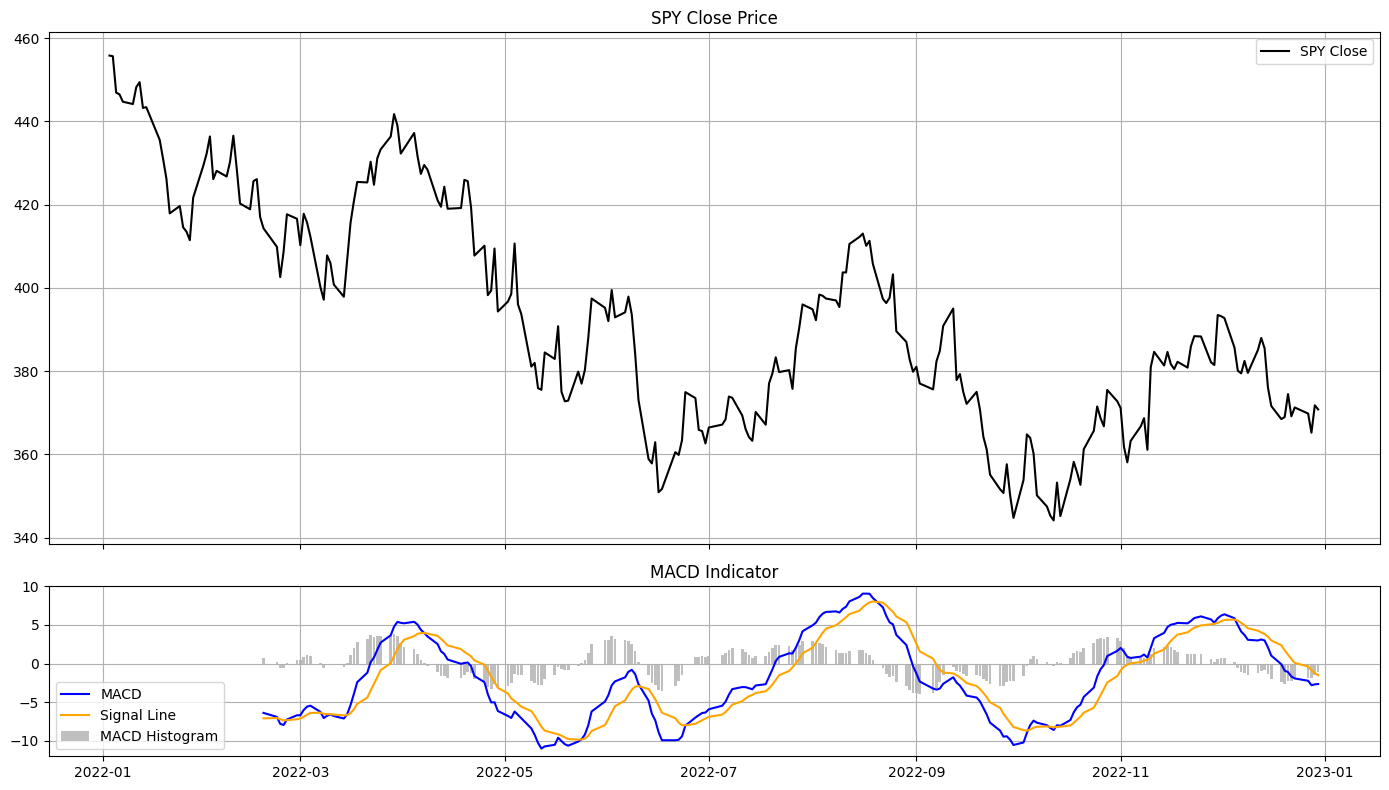

In [ ]:
# Step 2: Calculate MACD, Signal Line, and Histogram
macd, signal, hist = talib.MACD(spy['Close'].to_numpy().flatten(), fastperiod=12, slowperiod=26, signalperiod=9)

spy['MACD'] = macd
spy['Signal'] = signal
spy['Hist'] = hist

# Step 3: Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Close Price
ax1.plot(spy.index, spy['Close'], label='SPY Close', color='black')
ax1.set_title('SPY Close Price')
ax1.legend()
ax1.grid(True)

# Plot MACD
ax2.plot(spy.index, spy['MACD'], label='MACD', color='blue')
ax2.plot(spy.index, spy['Signal'], label='Signal Line', color='orange')
ax2.bar(spy.index, spy['Hist'], label='MACD Histogram', color='gray', alpha=0.5)
ax2.set_title('MACD Indicator')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=8fP_8gnYambvgyDFSyTaIA&n=Technical+Indicators)